In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Data : https://drive.google.com/uc?id=1UpLnYA48Vy_lGUMMLG-uQE1gf_Je12Lh

In [2]:
df = pd.read_csv('cars24-car-price-clean.csv')
df.head()

,selling_price,year,km_driven,mileage,engine,max_power,age,make,model,Individual,Trustmark Dealer,Diesel,Electric,LPG,Petrol,Manual,5,>5
0,-1.111046,-0.801317,1.195828,0.045745,-1.310754,-1.157780,0.801317,-0.433854,-1.125683,1.248892,-0.098382,-0.985275,-0.020095,-0.056917,1.024622,0.495818,0.444503,-0.424728
1,-0.223944,0.450030,-0.737872,-0.140402,-0.537456,-0.360203,-0.450030,-0.327501,-0.333227,1.248892,-0.098382,-0.985275,-0.020095,-0.056917,1.024622,0.495818,0.444503,-0.424728
2,-0.915058,-1.426990,0.035608,-0.582501,-0.537456,-0.404885,1.426990,-0.327501,-0.789807,1.248892,-0.098382,-0.985275,-0.020095,-0.056917,1.024622,0.495818,0.444503,-0.424728
3,-0.892365,-0.801317,-0.409143,0.329620,-0.921213,-0.693085,0.801317,-0.433854,-0.905265,1.248892,-0.098382,-0.985275,-0.020095,-0.056917,1.024622,0.495818,0.444503,-0.424728
4,-0.182683,0.137194,-0.544502,0.760085,0.042999,0.010435,-0.137194,-0.246579,-0.013096,-0.800710,-0.098382,1.014945,-0.020095,-0.056917,-0.975970,0.495818,0.444503,-0.424728


## Univariate Linear Regression from Scratch

In [3]:
X=df['max_power'].values
Y=df['selling_price'].values

In [4]:
type(X)

numpy.ndarray

In [5]:
type(Y)

numpy.ndarray

In [6]:
X.shape, Y.shape

((19820,), (19820,))

In [7]:
def predict(x,w):
    y_hat= w[1]*x + w[0]
    return y_hat

In [8]:
def error(X, Y, w):
    m=X.shape[0]
    total_error = 0.0
    for i in range(m):
        y_hat=predict(X[i],w)
        total_error+= (Y[i] - y_hat)**2
    return total_error/m

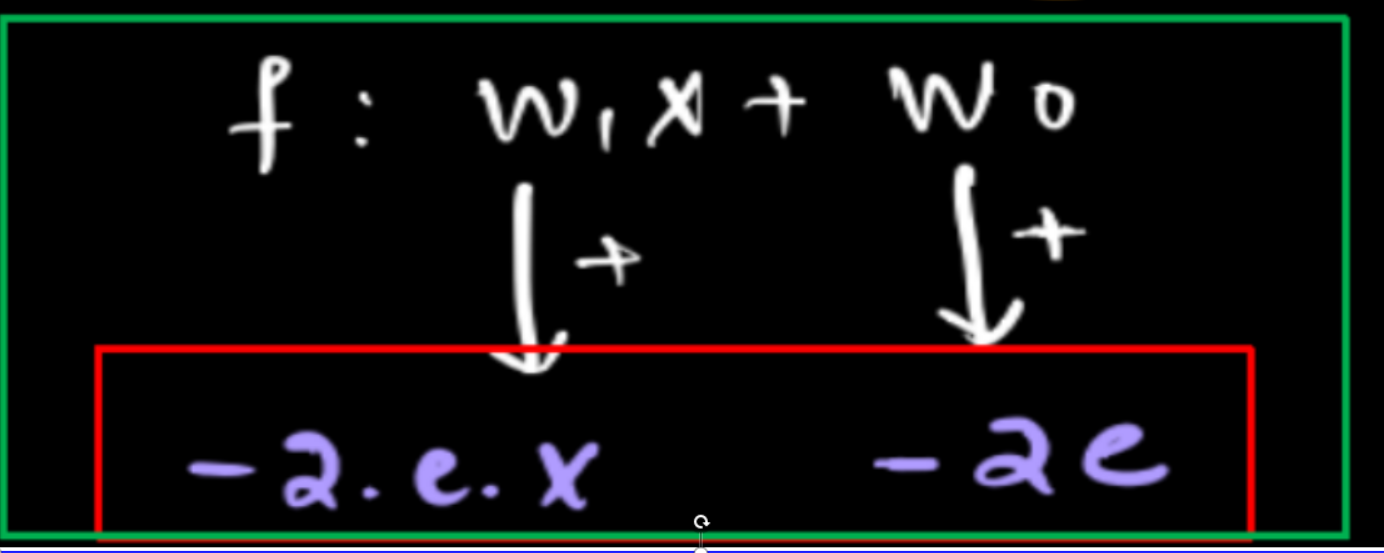

In [9]:
# dL/dW - we will use all the samples for gradient calculation
def gradient(X, Y, w):
  m = X.shape[0]
  grad = np.zeros((2,))
  for i in range(m):
    y_hat = predict(X[i], w)
    grad[1] += -2*(Y[i] - y_hat) * X[i]
    grad[0] += -2*(Y[i] - y_hat)
  return grad/m

## Training process of LR - Gradient Descent

In [10]:
def gradient_descent(X, Y, epochs=100, learning_rate=0.1):
    w = np.zeros((2,))
    w_list,e_list   = [], [] # this is just to log the intermediate e's and w's
    # run the loop 100 times
    for i in range(epochs):
      # calculate the gradient
      grad = gradient(X, Y, w)
      # keep updating the weights
      w[0] = w[0] - learning_rate * grad[0] 
      w[1] = w[1] - learning_rate * grad[1] 
      # store how weight was getting update in every iteration
      w_list.append([w[0], w[1]])
      # store how error/L is changing in every iteration
      e_list.append(error(X, Y, w))
    return w, w_list, e_list

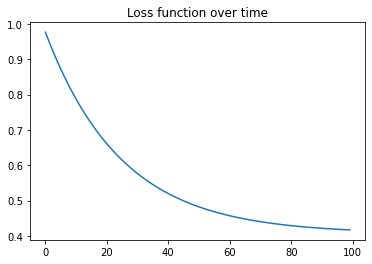

In [11]:
# too small of learning - takes too much time
w, w_list, e_list = gradient_descent(X,Y, epochs=100, learning_rate=0.01)
plt.plot(e_list)
plt.title("Loss function over time")
plt.show()

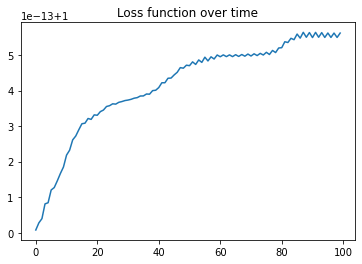

In [12]:
# too big of learning - never converges
w, w_list, e_list = gradient_descent(X, Y, epochs=100, learning_rate=1)
plt.plot(e_list)
plt.title("Loss function over time")
plt.show()

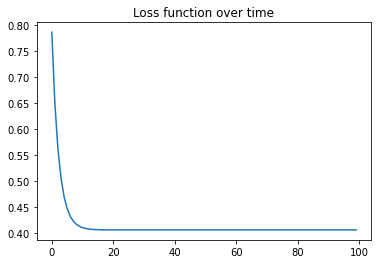

In [13]:
# perfect learning rate - converges quickly
w, w_list, e_list = gradient_descent(X, Y, epochs=100, learning_rate=0.1)
plt.plot(e_list)
plt.title("Loss function over time")
plt.show()

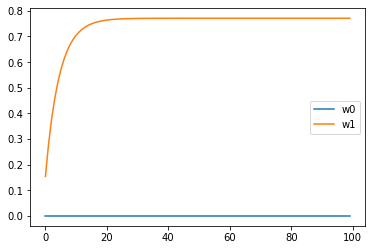

In [14]:
w_list = np.array(w_list)
plt.plot(w_list[:,0], label="w0")
plt.plot(w_list[:,1], label="w1")
plt.legend()
plt.show()

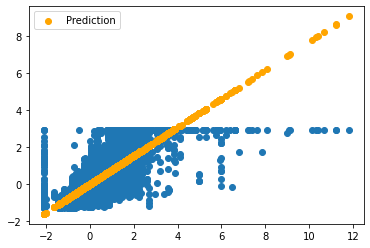

In [15]:
Y_hat = predict(X, w)
plt.scatter(X, Y)
plt.scatter(X, Y_hat, color="orange", label="Prediction")
plt.legend()
plt.show()

In [16]:
Y_hat

array([-0.89194167, -0.27749684, -0.31191952, ...,  0.09289119,
        0.72076087,  0.33522686])

In [17]:
def r2_score(Y,Y_hat):
    num = np.sum((Y-Y_hat)**2)
    denom = np.sum((Y- Y.mean())**2)
    score = (1 - num/denom)
    return score

In [18]:
r2_score(Y, Y_hat) # this is still on training data
# That the univariate predictor "max power" is explaining 59% of the variability in the data

0.5935005280317714

# Univariate Linear Regression using sklearn

In [19]:
from sklearn.linear_model import LinearRegression

In [20]:
model = LinearRegression()
type(model)

sklearn.linear_model._base.LinearRegression

In [21]:
model.fit(X, Y) 

ValueError: Expected 2D array, got 1D array instead:
array=[-1.15777962 -0.36020313 -0.40488529 ...  0.12057687  0.93557939
  0.43513924].
Reshape your data either using array.reshape(-1, 1) if your data has a single feature or array.reshape(1, -1) if it contains a single sample.

In [22]:
X.shape, Y.shape

((19820,), (19820,))

In [23]:
X=X.reshape(X.size,1)
Y=Y.reshape(Y.size,1)

In [24]:
X.shape, Y.shape

((19820, 1), (19820, 1))

In [25]:
model.fit(X, Y)

LinearRegression()

In [26]:
w1 = model.coef_  # w1, in case of Multivariate, this becomes a list w1, w2, w3..., wn

In [27]:
w0 = model.intercept_   # wo

In [28]:
w0, w1

(array([-1.56382574e-16]), array([[0.77038985]]))

In [29]:
Y_hat = model.predict(X)

In [30]:
model.score(Y, Y_hat) # this is probably not R-sq but something else, will see later

0.540779709149587

In [31]:
Y_hat

array([[-0.89194167],
       [-0.27749684],
       [-0.31191952],
       ...,
       [ 0.09289119],
       [ 0.72076087],
       [ 0.33522686]])

In [32]:
r2_score(Y, Y_hat)

0.5935005280317714

# Multivariate Linear Regression from Scratch

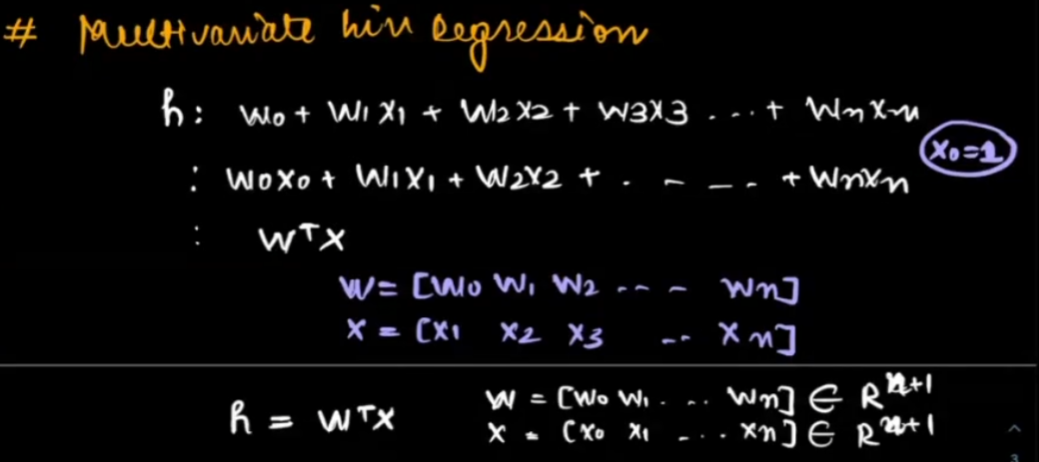

In [33]:
X = df[df.columns.drop('selling_price')]
Y = df["selling_price"]

In [34]:
X.shape, Y.shape

((19820, 17), (19820,))

In [35]:
X = X.to_numpy()
Y = Y.to_numpy()

In [36]:
# stack a columns of 1s with X
ones = np.ones((X.shape[0],1)) # 2D matrix defining a column of 1s
X = np.hstack((ones, X))
print(X.shape)

(19820, 18)


In [37]:
def hypothesis(X, weight): # same as predict for multivariate case
  return np.dot(X, weight)

In [38]:
def error(X, Y, w):
  # for every sample, calculate the squared error and later take the average
  m = X.shape[0]
  total_error = 0.0
  # this function shall work
  # can we write more optimised code? Use vectorised featurs of Numpy
  Y_hat = hypothesis(X, w)
  total_error = np.sum((Y - Y_hat)**2)/m
  return total_error

In [39]:
def gradient(X, Y, w):
  # grad = -2.E.X
  # X = (m, n+1)
  # E = (m,)
  # np.dot(X.T, E) --> (n+1,m) . (m,)
  # Output (grad) = (n+1,)
  m = X.shape[0]
  Y_hat = hypothesis(X, w)
  grad = 2*np.dot(X.T, (Y_hat - Y))
  return grad/m


In [40]:
def gradient_descent(X,y,learning_rate = 0.1,epochs=500):
    n = X.shape[1]
    weight = np.zeros((n,))
    error_list = []
    
    for i in range(epochs):
        e = error(X,y,weight)
        error_list.append(e)
        
        #Gradient descent
        grad = gradient(X,y,weight)
        weight = weight - learning_rate*grad
        
    return weight, error_list

In [41]:
weight, error_list = gradient_descent(X,Y)

In [42]:
weight

array([-7.92997241e-17,  6.49338324e-02, -1.82408891e-02, -4.85904514e-02,
        3.13372209e-02,  2.74641422e-02, -6.49338324e-02,  6.08300421e-02,
        7.94111472e-01, -1.69522784e-02, -3.46936443e-03,  1.43692475e-02,
        1.27486446e-02,  2.86932535e-03, -2.22411817e-02, -1.29482557e-02,
       -2.38676640e-02, -3.18144982e-02])

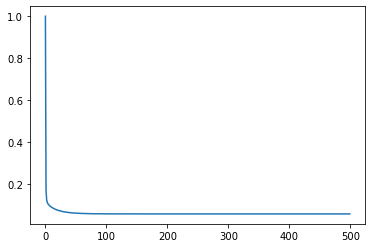

In [43]:
plt.plot(error_list)
plt.show()

In [44]:
Y_hat=hypothesis(X,weight)

In [45]:
r2_score(Y,Y_hat)

0.9421888967004275

# Multivariate Linear Regression using sklearn

In [46]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
print(X.shape,Y.shape)
model.fit(X,Y) # No need to add that extra column of 1s for sklearn
Y_hat = model.predict(X)
r2_score(Y,Y_hat)

(19820, 18) (19820,)


0.9421889572026914

In [47]:
model.coef_

array([ 0.        ,  0.06495341, -0.0182326 , -0.0486858 ,  0.03138293,
        0.0273649 , -0.06495341,  0.06078463,  0.79415416, -0.01695224,
       -0.00347518,  0.01408238,  0.01275246,  0.00283068, -0.02258059,
       -0.01293416, -0.02464122, -0.03265486])

In [48]:
len(model.coef_)

18

In [49]:
model.intercept_

-6.336516858810271e-17

In [50]:
model.score(X,Y)

0.9421889572026914

# VIF

In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [52]:
df = pd.read_csv('cars24-car-price-clean.csv')
df.head()

,selling_price,year,km_driven,mileage,engine,max_power,age,make,model,Individual,Trustmark Dealer,Diesel,Electric,LPG,Petrol,Manual,5,>5
0,-1.111046,-0.801317,1.195828,0.045745,-1.310754,-1.157780,0.801317,-0.433854,-1.125683,1.248892,-0.098382,-0.985275,-0.020095,-0.056917,1.024622,0.495818,0.444503,-0.424728
1,-0.223944,0.450030,-0.737872,-0.140402,-0.537456,-0.360203,-0.450030,-0.327501,-0.333227,1.248892,-0.098382,-0.985275,-0.020095,-0.056917,1.024622,0.495818,0.444503,-0.424728
2,-0.915058,-1.426990,0.035608,-0.582501,-0.537456,-0.404885,1.426990,-0.327501,-0.789807,1.248892,-0.098382,-0.985275,-0.020095,-0.056917,1.024622,0.495818,0.444503,-0.424728
3,-0.892365,-0.801317,-0.409143,0.329620,-0.921213,-0.693085,0.801317,-0.433854,-0.905265,1.248892,-0.098382,-0.985275,-0.020095,-0.056917,1.024622,0.495818,0.444503,-0.424728
4,-0.182683,0.137194,-0.544502,0.760085,0.042999,0.010435,-0.137194,-0.246579,-0.013096,-0.800710,-0.098382,1.014945,-0.020095,-0.056917,-0.975970,0.495818,0.444503,-0.424728


In [53]:
import statsmodels.api as sm

X = df[df.columns.drop('selling_price')]
Y = df["selling_price"] 

In [54]:
X.shape, Y.shape

((19820, 17), (19820,))

In [55]:
X

,year,km_driven,mileage,engine,max_power,age,make,model,Individual,Trustmark Dealer,Diesel,Electric,LPG,Petrol,Manual,5,>5
0,-0.801317,1.195828,0.045745,-1.310754,-1.157780,0.801317,-0.433854,-1.125683,1.248892,-0.098382,-0.985275,-0.020095,-0.056917,1.024622,0.495818,0.444503,-0.424728
1,0.450030,-0.737872,-0.140402,-0.537456,-0.360203,-0.450030,-0.327501,-0.333227,1.248892,-0.098382,-0.985275,-0.020095,-0.056917,1.024622,0.495818,0.444503,-0.424728
2,-1.426990,0.035608,-0.582501,-0.537456,-0.404885,1.426990,-0.327501,-0.789807,1.248892,-0.098382,-0.985275,-0.020095,-0.056917,1.024622,0.495818,0.444503,-0.424728
3,-0.801317,-0.409143,0.329620,-0.921213,-0.693085,0.801317,-0.433854,-0.905265,1.248892,-0.098382,-0.985275,-0.020095,-0.056917,1.024622,0.495818,0.444503,-0.424728
4,0.137194,-0.544502,0.760085,0.042999,0.010435,-0.137194,-0.246579,-0.013096,-0.800710,-0.098382,1.014945,-0.020095,-0.056917,-0.975970,0.495818,0.444503,-0.424728
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19815,0.762867,0.218923,0.950886,-0.215410,-0.694202,-0.762867,0.724475,0.091865,-0.800710,-0.098382,1.014945,-0.020095,-0.056917,-0.975970,0.495818,0.444503,-0.424728
19816,1.388540,-0.776546,-0.466159,-0.198054,-0.156899,-1.388540,-0.433854,0.112857,-0.800710,-0.098382,-0.985275,-0.020095,-0.056917,1.024622,0.495818,-2.249703,2.354446
19817,0.137194,0.170967,0.380810,0.042999,0.120577,-0.137194,-0.240799,-0.448684,-0.800710,-0.098382,1.014945,-0.020095,-0.056917,-0.975970,0.495818,0.444503,-0.424728
19818,0.450030,72.355997,-0.815185,1.356256,0.935579,-0.450030,0.123346,0.328027,-0.800710,-0.098382,1.014945,-0.020095,-0.056917,-0.975970,0.495818,-2.249703,2.354446


In [56]:
X_sm = sm.add_constant(X)
X_sm.shape

D:\Subhrajit\anaconda3\lib\site-packages\statsmodels\tsa\tsatools.py:142: FutureWarning: In a future version of pandas all arguments of concat except for the argument 'objs' will be keyword-only
  x = pd.concat(x[::order], 1)


(19820, 18)

In [57]:
X_sm

,const,year,km_driven,mileage,engine,max_power,age,make,model,Individual,Trustmark Dealer,Diesel,Electric,LPG,Petrol,Manual,5,>5
0,1.0,-0.801317,1.195828,0.045745,-1.310754,-1.157780,0.801317,-0.433854,-1.125683,1.248892,-0.098382,-0.985275,-0.020095,-0.056917,1.024622,0.495818,0.444503,-0.424728
1,1.0,0.450030,-0.737872,-0.140402,-0.537456,-0.360203,-0.450030,-0.327501,-0.333227,1.248892,-0.098382,-0.985275,-0.020095,-0.056917,1.024622,0.495818,0.444503,-0.424728
2,1.0,-1.426990,0.035608,-0.582501,-0.537456,-0.404885,1.426990,-0.327501,-0.789807,1.248892,-0.098382,-0.985275,-0.020095,-0.056917,1.024622,0.495818,0.444503,-0.424728
3,1.0,-0.801317,-0.409143,0.329620,-0.921213,-0.693085,0.801317,-0.433854,-0.905265,1.248892,-0.098382,-0.985275,-0.020095,-0.056917,1.024622,0.495818,0.444503,-0.424728
4,1.0,0.137194,-0.544502,0.760085,0.042999,0.010435,-0.137194,-0.246579,-0.013096,-0.800710,-0.098382,1.014945,-0.020095,-0.056917,-0.975970,0.495818,0.444503,-0.424728
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19815,1.0,0.762867,0.218923,0.950886,-0.215410,-0.694202,-0.762867,0.724475,0.091865,-0.800710,-0.098382,1.014945,-0.020095,-0.056917,-0.975970,0.495818,0.444503,-0.424728
19816,1.0,1.388540,-0.776546,-0.466159,-0.198054,-0.156899,-1.388540,-0.433854,0.112857,-0.800710,-0.098382,-0.985275,-0.020095,-0.056917,1.024622,0.495818,-2.249703,2.354446
19817,1.0,0.137194,0.170967,0.380810,0.042999,0.120577,-0.137194,-0.240799,-0.448684,-0.800710,-0.098382,1.014945,-0.020095,-0.056917,-0.975970,0.495818,0.444503,-0.424728
19818,1.0,0.450030,72.355997,-0.815185,1.356256,0.935579,-0.450030,0.123346,0.328027,-0.800710,-0.098382,1.014945,-0.020095,-0.056917,-0.975970,0.495818,-2.249703,2.354446


In [58]:
# Simple Linear Regression - OLS (Ordinary Least Squares)
sm_model = sm.OLS(Y,X_sm).fit()
print(sm_model.summary())

                            OLS Regression Results                            
Dep. Variable:          selling_price   R-squared:                       0.942
Model:                            OLS   Adj. R-squared:                  0.942
Method:                 Least Squares   F-statistic:                 1.898e+04
Date:                Sat, 26 Aug 2023   Prob (F-statistic):               0.00
Time:                        21:26:15   Log-Likelihood:                 125.80
No. Observations:               19820   AIC:                            -215.6
Df Residuals:                   19802   BIC:                            -73.51
Df Model:                          17                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const             2.689e-17      0.002  

In [59]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [60]:
vif = pd.DataFrame()
X_t =X
vif["Features"] =  X_t.columns

In [61]:
X_t.values

array([[-8.01316544e-01,  1.19582817e+00,  4.57451688e-02, ...,
         4.95818203e-01,  4.44503185e-01, -4.24728453e-01],
       [ 4.50030281e-01, -7.37872078e-01, -1.40401980e-01, ...,
         4.95818203e-01,  4.44503185e-01, -4.24728453e-01],
       [-1.42698996e+00,  3.56080197e-02, -5.82501459e-01, ...,
         4.95818203e-01,  4.44503185e-01, -4.24728453e-01],
       ...,
       [ 1.37193575e-01,  1.70967037e-01,  3.80810037e-01, ...,
         4.95818203e-01,  4.44503185e-01, -4.24728453e-01],
       [ 4.50030281e-01,  7.23559971e+01, -8.15185395e-01, ...,
         4.95818203e-01, -2.24970266e+00,  2.35444551e+00],
       [ 1.38854040e+00, -8.73231095e-01, -3.49817523e-01, ...,
        -2.01686827e+00,  4.44503185e-01, -4.24728453e-01]])

In [62]:
vif["VIF"]=[variance_inflation_factor(X_t.values,i) for i in range(len(X_t.columns))]
vif.sort_values(by="VIF",ascending=False)

D:\Subhrajit\anaconda3\lib\site-packages\statsmodels\stats\outliers_influence.py:193: RuntimeWarning: divide by zero encountered in double_scalars
  vif = 1. / (1. - r_squared_i)


,Features,VIF
0,year,inf
5,age,inf
13,Petrol,17.949202
10,Diesel,17.033569
16,>5,13.316024
15,5,12.077738
3,engine,6.271515
7,model,5.801318
4,max_power,5.079379
6,make,3.204401


In [63]:
# VIF > 10 is an indicator of multi-collinerity 
# but doesnt give us a license to blindly remove all features with VIF>10
# LETS REMOVE ONE OF THE FEATURES
cols2 = vif.sort_values(by = "VIF", ascending=False)["Features"][1:].values

In [64]:
X = df[cols2]
Y = df["selling_price"] 
X_sm = sm.add_constant(X)
sm_model = sm.OLS(Y, X_sm).fit()
print(sm_model.summary())

                            OLS Regression Results                            
Dep. Variable:          selling_price   R-squared:                       0.942
Model:                            OLS   Adj. R-squared:                  0.942
Method:                 Least Squares   F-statistic:                 2.017e+04
Date:                Sat, 26 Aug 2023   Prob (F-statistic):               0.00
Time:                        21:26:17   Log-Likelihood:                 125.84
No. Observations:               19820   AIC:                            -217.7
Df Residuals:                   19803   BIC:                            -83.48
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const             2.689e-17      0.002  

D:\Subhrajit\anaconda3\lib\site-packages\statsmodels\tsa\tsatools.py:142: FutureWarning: In a future version of pandas all arguments of concat except for the argument 'objs' will be keyword-only
  x = pd.concat(x[::order], 1)


In [65]:
vif = pd.DataFrame()
X_t = X[cols2]
vif["Features"] = X_t.columns
vif["VIF"] = [variance_inflation_factor(X_t.values, i) for i in range(len(X_t.columns))]
vif.sort_values(by = "VIF", ascending=False)

,Features,VIF
1,Petrol,17.949208
2,Diesel,17.033579
3,>5,13.316028
4,5,12.077742
5,engine,6.272148
6,model,5.801345
7,max_power,5.079379
8,make,3.204460
9,mileage,3.149380
0,age,1.922833


In [66]:
# VIF > 10 is an indicator of multi-collinerity 
# but doesnt give us a license to blindly remove all features with VIF>10
# LETS REMOVE ONE OF THE FEATURES
cols3 = vif.sort_values(by = "VIF", ascending=False)["Features"][1:].values

In [67]:
X = df[cols3]
Y = df["selling_price"] 
X_sm = sm.add_constant(X)
sm_model = sm.OLS(Y, X_sm).fit()
print(sm_model.summary())

                            OLS Regression Results                            
Dep. Variable:          selling_price   R-squared:                       0.942
Model:                            OLS   Adj. R-squared:                  0.942
Method:                 Least Squares   F-statistic:                 2.151e+04
Date:                Sat, 26 Aug 2023   Prob (F-statistic):               0.00
Time:                        21:26:18   Log-Likelihood:                 120.97
No. Observations:               19820   AIC:                            -209.9
Df Residuals:                   19804   BIC:                            -83.63
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const             2.689e-17      0.002  

D:\Subhrajit\anaconda3\lib\site-packages\statsmodels\tsa\tsatools.py:142: FutureWarning: In a future version of pandas all arguments of concat except for the argument 'objs' will be keyword-only
  x = pd.concat(x[::order], 1)


# Check for Heteroskadisticity

In [68]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
X = df[df.columns.drop('selling_price')]
Y = df["selling_price"]
X = X.to_numpy()
Y = Y.to_numpy() 
model.fit(X, Y) # no need to that extra column of 1s for sklearn
Y_hat = model.predict(X)

In [69]:
errors = Y - Y_hat

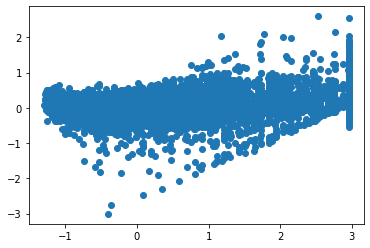

In [70]:
import matplotlib.pyplot as plt
plt.scatter(Y, errors)
plt.show()